# Analisando o Dataset

Este notebook tem como objetivo realizar a análise exploratória dos dados de áudio respiratório utilizados no projeto, etapa anterior à geração dos espectrogramas que servirão de entrada para a classificação por imagem. A análise busca compreender a estrutura, a qualidade e as limitações dos dados brutos antes do início do pré-processamento, de modo a fundamentar as decisões metodológicas das etapas seguintes.
O projeto utiliza dois datasets públicos de sons respiratórios, ICBHI 2017 e KAUH 2021, que foram combinados em um único conjunto de dados. Essa combinação se mostrou necessária porque o ICBHI 2017, isoladamente, apresenta diversas classes com número de amostras insuficiente para o treinamento de um modelo de classificação, como Asthma (1 amostra) e LRTI (2 amostras). O dataset KAUH 2021 contribui justamente com maior quantidade de amostras para essas classes, como 96 amostras de Asthma, além de introduzir diagnósticos ausentes no ICBHI, como Heart Failure, Bronchitis e Pleural Effusion. Com a combinação, o total de amostras passa de 920 (ICBHI) ou 324 (KAUH) isoladamente para 1244, ampliando a cobertura para dez das doze classes definidas para o projeto, ainda que o desbalanceamento entre classes não seja eliminado por essa estratégia.

A análise está organizada em três partes. Inicialmente, é examinado o dataset ICBHI 2017, com avaliação do tamanho do conjunto, da distribuição de classes, das características demográficas dos pacientes (idade e sexo) e da duração das gravações. Em seguida, o mesmo conjunto de análises é repetido para o dataset KAUH 2021, permitindo comparação direta entre as duas fontes. Por fim, é apresentado o dataset combinado, com verificação de integridade da unificação e análise da distribuição de classes segmentada por fonte de origem, evidenciando a complementaridade entre os dois conjuntos.

### Visão geral dos datasets

Os datasets públicos utilizados no projeto consistem em gravações de sons respiratórios obtidas em contexto clínico, acompanhadas de anotações e metadados associados. As bases foram escolhidas devido ao amplo uso em pesquisas de classificação automática de doenças pulmonares.
| Base de Dados | Endereço na Web | Resumo descritivo |
|---|---|---|
| ICBHI Challenge (2017) | https://bhichallenge.med.auth.gr/ICBHI_2017_Challenge | Dataset utilizado no ICBHI 2017 Respiratory Sound Challenge. Contém gravações respiratórias de pacientes, anotadas com 8 doenças pulmonares, além de anotações de ciclos respiratórios, sibilos e estalos realizadas por especialistas. Contém 920 amostras de 126 pacientes. |
| KAUH (2021) Respiratory Sound Dataset | https://data.mendeley.com/datasets/jwyy9np4gv/3 | Dataset com gravações respiratórias obtidas com estetoscópio digital e disponibilizadas em diferentes modos de filtragem acústica, anotadas com 8 doenças cardiopulmonares. Contém 336 amostras de 112 pacientes. |

Os áudios de ambas as bases estão disponíveis no formato .wav. As anotações, no entanto, são fornecidas em formatos distintos:

ICBHI 2017: as anotações estão em arquivos de texto (.txt), sendo um deles responsável por relacionar o identificador de cada paciente ao respectivo diagnóstico (ICBHI_Challenge_diagnosis.txt), outro contendo informações demográficas (ICBHI_Challenge_demographic_information.txt), e um terceiro definindo a divisão oficial entre treino e teste proposta pelo desafio (ICBHI_challenge_train_test.txt).
KAUH (2021): as anotações estão concentradas em uma planilha Excel, contendo dados do paciente, informações sobre a aquisição do exame (modo de filtragem do estetoscópio, por exemplo) e o diagnóstico associado, quando houver.

Em ambos os casos, os dados não estão originalmente balanceados entre as classes: a classe COPD (Doença Pulmonar Obstrutiva Crônica) concentra a maior parte das amostras, enquanto patologias como Asma e Bronquiectasia possuem poucas amostras disponíveis. Esse desbalanceamento é um dos principais desafios do projeto e é tratado em diferentes etapas do pipeline, descritas na seção de Metodologia.

### Configuração do Ambiente e Definição de Constantes

O bloco importa as bibliotecas utilizadas na análise: librosa para leitura e processamento dos arquivos de áudio, pandas para organização dos metadados em tabelas, matplotlib para geração de gráficos e defaultdict para contagens agregadas. O ajuste do sys.path é necessário para que as classes definidas no módulo modules.datasets possam ser importadas no notebook. São importadas quatro classes responsáveis pela leitura dos datasets: ICBHIAudioDataset e KAUHAudioDataset, específicas para cada fonte de dados, CombinedAudioDataset, que une os dois conjuntos, e AudioDataset, classe base comum às demais. A lista ALL_CLASSES define os doze rótulos de diagnóstico considerados no projeto, presentes nos dois datasets combinados.

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

import librosa
import pandas as pd
from matplotlib import pyplot as plt
from collections import defaultdict

from modules.datasets import ICBHIAudioDataset, KAUHAudioDataset, CombinedAudioDataset, AudioDataset

ALL_CLASSES = [
    "Asthma",
    "Bronchiectasis",
    "Bronchiolitis",
    "Bronchitis",
    "COPD",
    "Healthy",
    "Heart Failure",
    "LRTI",
    "Lung Fibrosis",
    "Pleural Effusion",
    "Pneumonia",
    "URTI",
]

O caminho DATA_FOLDER é definido apontando para a pasta de dados brutos, localizada no diretório pai do notebook. Em seguida, é feita uma verificação simples para alertar caso o diretório não exista, evitando falhas em etapas posteriores que dependem do acesso aos arquivos de áudio.

In [2]:
DATA_FOLDER = os.path.join(os.path.dirname(os.getcwd()), "data/raw")
if not os.path.exists(DATA_FOLDER):
    print(f"Data directory not found at {DATA_FOLDER}. Please ensure the data is downloaded and placed in the correct location.")

## Datasets Distributions

### ICBHI 2017

É instanciada a classe ICBHIAudioDataset, recebendo o caminho da pasta de dados, o parâmetro "all" para carregar todos os subconjuntos disponíveis e a lista ALL_CLASSES para restringir os rótulos às classes definidas. Em seguida, é impresso o tamanho total do dataset e exibidas as dez primeiras linhas da tabela de metadados por meio de data.head(10).

In [3]:
icbhi_dataset = ICBHIAudioDataset(DATA_FOLDER, "all", classes=ALL_CLASSES)
print(f"Dataset size: {len(icbhi_dataset)} samples")
icbhi_dataset.data.head(10)

Dataset size: 920 samples


,Source,FilePath,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label
0,ICBHI,ICBHI/ICBHI_final_database/101_1b1_Al_sc_Medit...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,11
1,ICBHI,ICBHI/ICBHI_final_database/101_1b1_Pr_sc_Medit...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,11
2,ICBHI,ICBHI/ICBHI_final_database/102_1b1_Ar_sc_Medit...,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,5
3,ICBHI,ICBHI/ICBHI_final_database/103_2b2_Ar_mc_LittC...,Asthma,70.00,F,33.00,NaN,NaN,I103,2b2,Ar,mc,LittC2SE,0
4,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Al_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Al,sc,Litt3200,4
5,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Ar_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ar,sc,Litt3200,4
6,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Ll_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ll,sc,Litt3200,4
7,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Lr_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Lr,sc,Litt3200,4
8,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Pl_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pl,sc,Litt3200,4
9,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Pr_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pr,sc,Litt3200,4


O dataset carregado contém 920 amostras. A tabela de metadados apresenta, para cada gravação, informações como diagnóstico, idade, sexo, BMI (para pacientes adultos) ou peso e altura (para pacientes pediátricos), identificador do paciente, ponto de auscultação no tórax (ChestLocation), modo de aquisição e equipamento utilizado na gravação. Observa-se que um mesmo paciente pode ter múltiplas gravações associadas, correspondentes a diferentes pontos de auscultação, como visto no paciente 104, com seis registros de COPD em pontos distintos (Al, Ar, Ll, Lr, Pl, Pr).

#### Unit Test

É executado o método unit_test, passando o índice 0, com o objetivo de inspecionar uma amostra específica do dataset e validar se o carregamento do áudio e dos metadados correspondentes está correto.

Sample 0:
  File name: 101_1b1_Al_sc_Meditron.wav
  Label: 11 (URTI)
  Sample rate: 44100
  Audio shape: (882000,)
  Audio dtype: float32
  Audio min value: -0.200
  Audio max value: 0.415
  Duration (s): 20.00


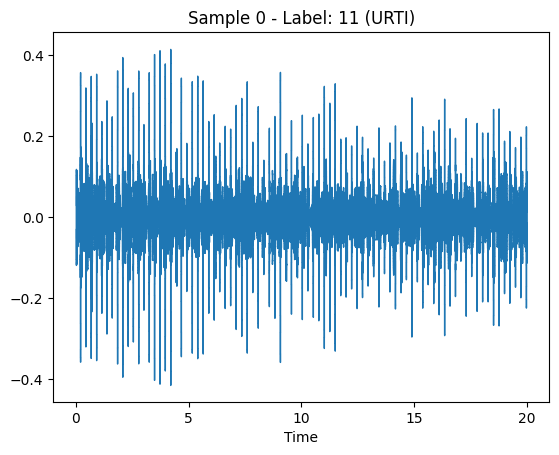

In [4]:
icbhi_dataset.unit_test(idx=0)

A amostra de índice 0 corresponde ao arquivo 101_1b1_Al_sc_Meditron.wav, com rótulo 11 (URTI). A gravação possui taxa de amostragem de 44100 Hz, duração de 20 segundos e amplitude variando entre -0,200 e 0,415. O teste confirma que o áudio foi carregado corretamente, com formato e tipo de dado (float32) consistentes com o esperado.

#### Class Distribution

A função plot_label_distribution é chamada com o dataset ICBHI carregado como argumento, gerando a contagem de amostras por diagnóstico e o respectivo gráfico de barras.

In [5]:
def plot_label_distribution(dataset: AudioDataset):
    """
    Plot the distribution of labels in the dataset.
    Args:
        dataset (AudioDataset): The dataset containing label information.
    """
    data = dataset.data
    label_counts = data["Diagnosis"].value_counts()
    display(label_counts)
    label_counts.plot(kind="bar")
    plt.title("Label Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

Diagnosis
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
LRTI                2
Asthma              1
Name: count, dtype: int64

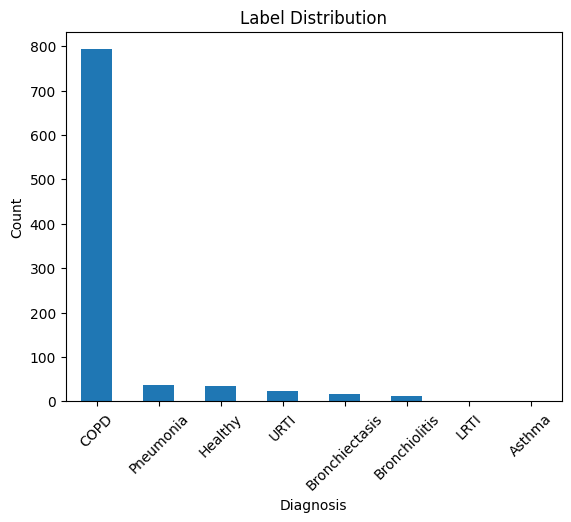

In [6]:
plot_label_distribution(icbhi_dataset)

A distribuição de classes do dataset ICBHI 2017 mostra forte desbalanceamento. COPD concentra 793 das 920 amostras, o que corresponde a aproximadamente 86% do total. As demais classes apresentam contagens substancialmente menores: Pneumonia (37), Healthy (35), URTI (23), Bronchiectasis (16) e Bronchiolitis (13). LRTI e Asthma possuem apenas 2 e 1 amostra, respectivamente.

#### Demographics

Analise das características demográficas dos pacientes presentes no dataset ICBHI 2017, especificamente idade e sexo, de modo a identificar possíveis viéses na composição da amostra.

É definida a função plot_demographic_distribution, que recebe um objeto AudioDataset e gera dois gráficos lado a lado. O primeiro é um histograma com 100 bins da coluna Age, e o segundo é um gráfico de barras com a contagem de valores da coluna Sex obtida via value_counts(). A função é então chamada com o dataset ICBHI carregado.

In [7]:
def plot_demographic_distribution(dataset: AudioDataset):
    """
    Plot the distribution of demographic features in the dataset (Age and Sex).
    Args:
        dataset (AudioDataset): The dataset containing demographic information.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    data = dataset.data.copy()

    data.drop_duplicates(subset=["PatientId"], inplace=True)  # Ensure unique patients for demographic analysis
    
    # Age distribution
    data["Age"].plot(kind="hist", bins=100, ax=axes[0], color="skyblue")
    axes[0].set_title("Age Distribution")
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("Count")

    # Sex distribution
    data["Sex"].value_counts().plot(kind="bar", ax=axes[1], color="salmon")
    axes[1].set_title("Sex Distribution")
    axes[1].set_xlabel("Sex")
    axes[1].set_ylabel("Count")

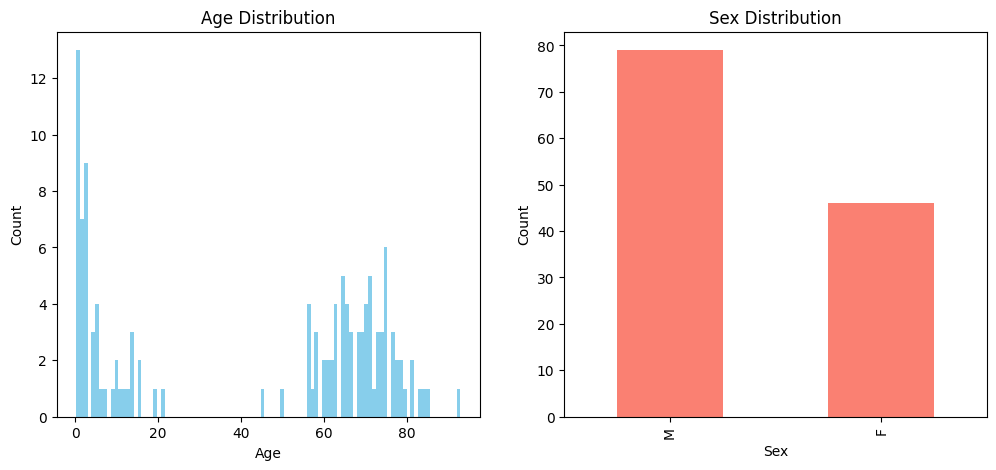

In [8]:
plot_demographic_distribution(icbhi_dataset)

A distribuição de idade apresenta padrão bimodal, com uma concentração de pacientes pediátricos próximos a 0 anos e uma concentração maior e mais dispersa entre aproximadamente 50 e 85 anos, com pico mais acentuado próximo aos 75 anos. Há praticamente ausência de pacientes entre 20 e 45 anos, o que indica uma lacuna etária relevante na amostra.
Em relação ao sexo, observa-se desbalanceamento moderado, com aproximadamente 590 registros do sexo masculino contra cerca de 325 do sexo feminino, totalizando uma proporção próxima de 65% para 35%.
Essa composição demográfica, concentrada em idosos e crianças pequenas, é coerente com o perfil de pacientes do dataset ICBHI 2017, majoritariamente associado a diagnósticos de COPD, condição predominante em pacientes idosos, conforme observado na distribuição de classes.

#### Duration

Análise  da distribuição da duração das gravações de áudio, tanto de forma geral quanto segmentada por diagnóstico, de modo a verificar a uniformidade temporal dos arquivos e identificar a necessidade de padronização antes da extração dos espectrogramas.

É definida a função plot_recording_duration_distribution, que itera sobre todas as linhas do DataFrame de metadados, calculando a duração de cada arquivo de áudio por meio de librosa.get_duration. As durações são armazenadas em uma lista geral e também agrupadas por diagnóstico em um defaultdict. São impressos os valores mínimo e máximo de duração encontrados, seguidos por um histograma geral da distribuição de durações e, em seguida, um conjunto de subplots, um para cada classe de diagnóstico, exibindo a distribuição de duração específica daquela classe. A função é então chamada com o dataset ICBHI.

In [9]:
def plot_recording_duration_distribution(dataset: AudioDataset):
    """
    Plot the distribution of recording durations in the dataset.
    Args:
        dataset (AudioDataset): The dataset containing recording duration information.
    """
    durations = []
    durations_by_label = defaultdict(list)
    for _, row in dataset.data.iterrows():
        label = row["Diagnosis"]
        file_path = dataset.root / row["FilePath"]
        duration = librosa.get_duration(path=file_path)
        durations.append(duration)
        durations_by_label[label].append(duration)

    shortest_duration = min(durations)
    longest_duration = max(durations)
    print(f"Shortest recording duration: {shortest_duration:.2f} seconds")
    print(f"Longest recording duration: {longest_duration:.2f} seconds")

    # Plot overall distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    pd.Series(durations).plot(kind="hist", bins=50, ax=ax)
    ax.set_title("Recording Duration Distribution")
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Count")
    plt.show()

    # Plot distribution by label
    num_classes = len(durations_by_label)
    num_rows = (num_classes + 1) // 2
    num_cols = 2 if num_classes > 1 else 1
    fig, ax = plt.subplots(num_rows, num_cols, figsize=(12, num_rows * 4))
    ax = ax.flatten() if num_classes > 1 else [ax]
    for i, (diagnosis, durations) in enumerate(durations_by_label.items()):
        pd.Series(durations).plot(kind="hist", bins=50, ax=ax[i], alpha=0.5, label=diagnosis)
        ax[i].set_title(f"{diagnosis}")
        ax[i].set_xlabel("Duration (seconds)")
        ax[i].set_ylabel("Count")
        ax[i].legend()
    plt.tight_layout()
    plt.show()

Shortest recording duration: 7.86 seconds
Longest recording duration: 86.20 seconds


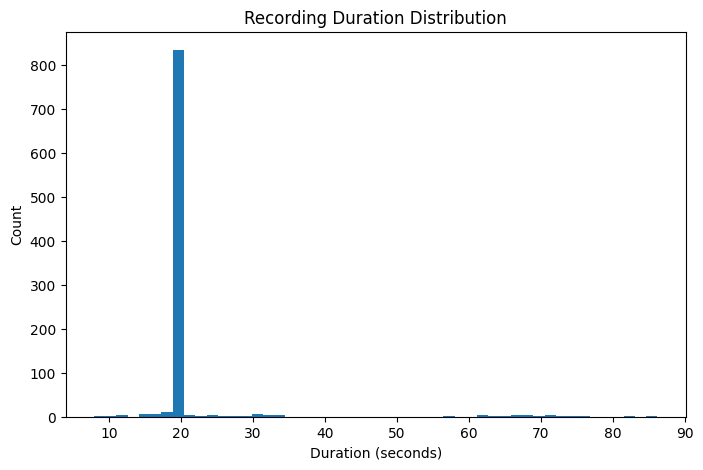

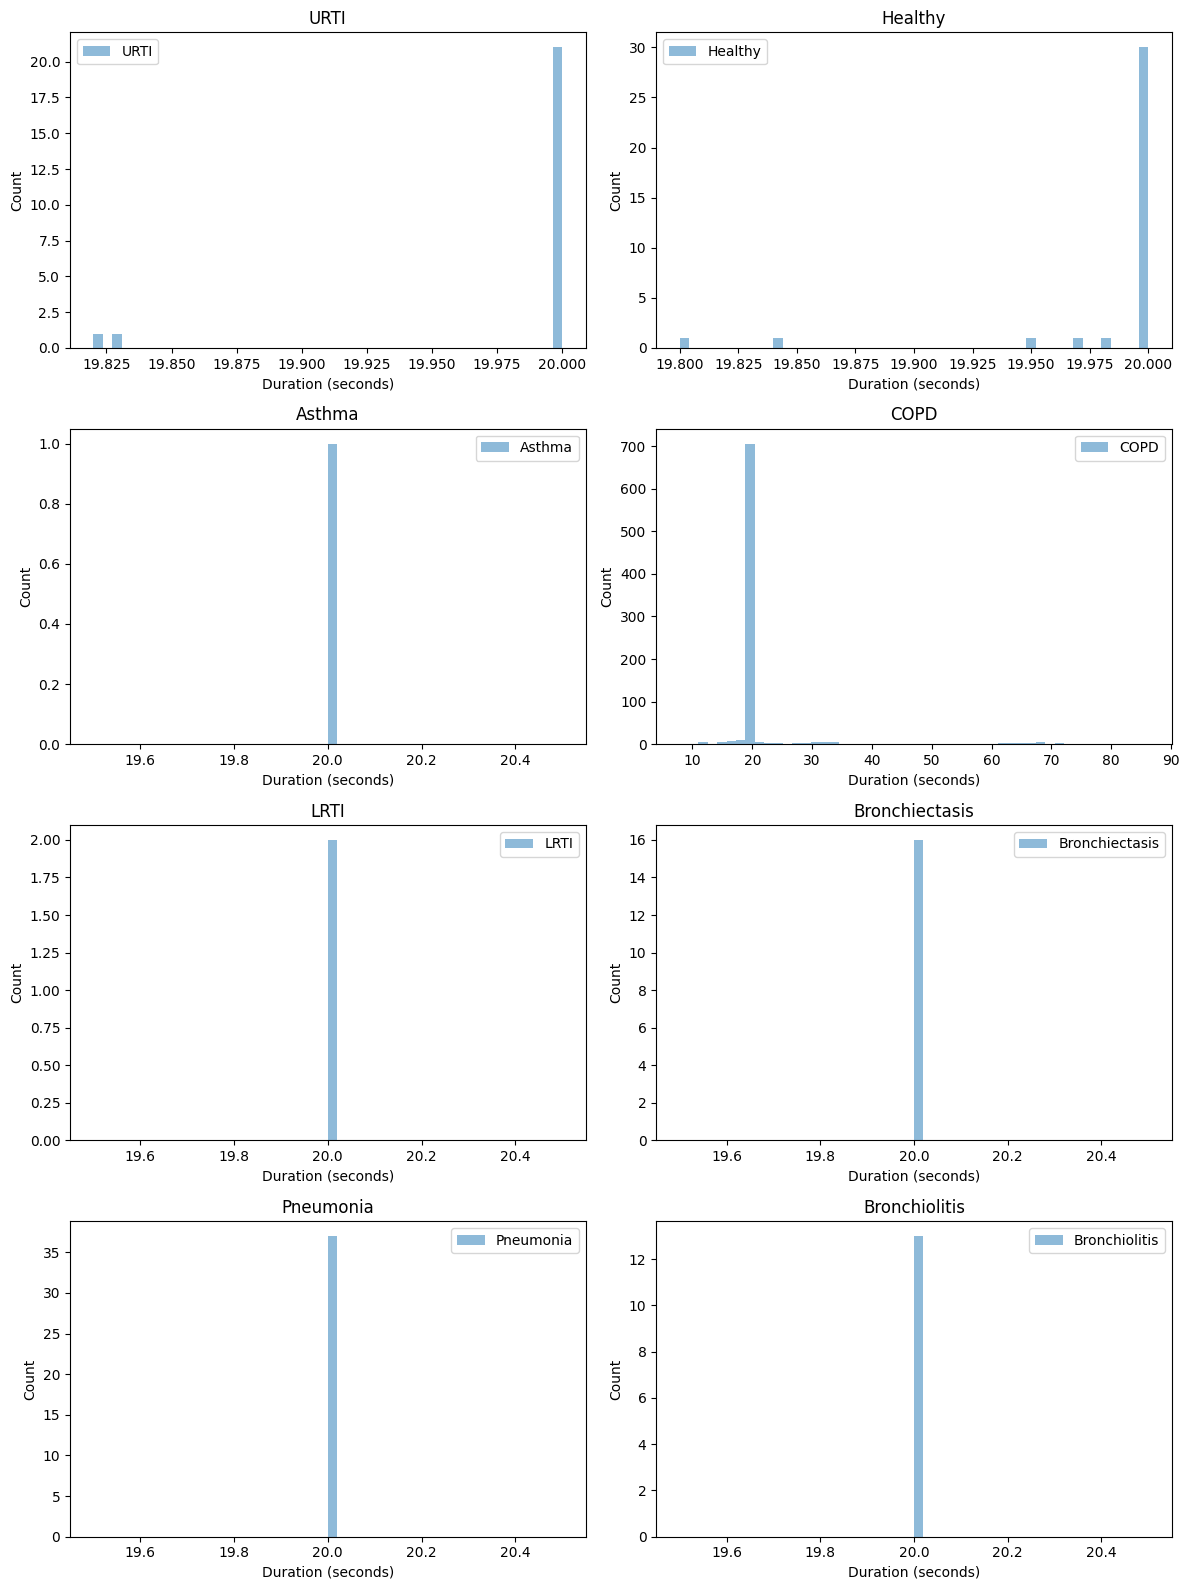

In [10]:
plot_recording_duration_distribution(icbhi_dataset)

A duração mínima registrada foi de 7,86 segundos e a máxima de 86,20 segundos. O primeiro histograma ilusta distribuição das durações dos sinais de áudio, evidenciando uma concentração de amostras com duração de 20 segundos, com mais de 800 das 920 amostras nesse valor. No entanto, observa-se a existência de gravações com durações discrepantes, apenas uma pequena quantidade dispersa entre 10 e 85 segundos, alcançando valores significativamente inferiores e superiores à média do conjunto de dados. Essa heterogeneidade temporal pode dificultar o processo de treinamento dos modelos de aprendizado profundo, devido à inconsistência no comprimento das entradas.

Adicionalmente, foram feitas análises individuais para cada classe do dataset, permitindo uma análise mais detalhada da distribuição das durações entre as diferentes patologias respiratórias. Para a classe Asthma (Asma), observa-se apenas uma amostra, com duração concentrada em aproximadamente 20 segundos. De forma semelhante, as classes Bronchiectasis (Bronquiectasia) e Bronchiolitis (Bronquiolite) apresentam, respectivamente, 16 e 13 amostras, todas concentradas na mesma duração.
A classe COPD (Doença Pulmonar Obstrutiva Crônica) apresenta um comportamento significativamente diferente das demais, contendo mais de 700 amostras. Apesar de existir uma variação nas durações, aproximadamente entre 10 e 30 segundos, nota-se uma predominância expressiva de sinais próximos de 20 segundos, representando a maior parte das amostras dessa classe.
Para a classe Healthy (Saudável), observa-se aproximadamente 30 amostras, também concentradas próximas de 20 segundos, com pequenas variações temporais inferiores a 0,2 segundos. Já a classe LRTI (Infecção do Trato Respiratório Superior) apresenta apenas duas amostras, ambas próximas de 20 segundos.
Na classe Pneumonia, observa-se cerca de 40 amostras concentradas em torno de 20 segundos de duração. Por fim, a classe URTI (Infecção do Trato Respiratório Inferior) apresenta aproximadamente 25 amostras próximas de 20 segundos, além de uma amostra com pequeno desvio temporal, em torno de 19,85 segundos.
A partir dessa análise, é possível observar não apenas diferenças nas durações dos sinais entre algumas amostras, mas principalmente um forte desbalanceamento entre as classes do conjunto de dados, que motivou a estratégia de janelamento descrita na seção de Metodologia.




### KAUH 2021

Esta seção tem como objetivo carregar o dataset KAUH 2021 e verificar a integridade dos dados e metadados associados a cada gravação, seguindo o mesmo procedimento aplicado ao dataset ICBHI 2017.

É instanciada a classe KAUHAudioDataset, recebendo o caminho da pasta de dados, o parâmetro "all" e a lista ALL_CLASSES. É impresso o tamanho total do dataset e exibidas as dez primeiras linhas da tabela de metadados.

In [11]:
kauh_dataset = KAUHAudioDataset(DATA_FOLDER, "all", classes=ALL_CLASSES)
print(f"Dataset size: {len(kauh_dataset)} samples")
kauh_dataset.data.head(10)

Dataset size: 324 samples


,Source,FilePath,Diagnosis,FilterCode,PatientId,Sound type,ChestLocation,Age,Sex,Label
0,KAUH,"KAUH/Audio Files/BP100_N,N,P R M,70,F.wav",Healthy,B,P100,N,P R M,70.0,F,5
1,KAUH,"KAUH/Audio Files/BP101_Asthma,E W,P L M,12,F.wav",Asthma,B,P101,E W,P L M,12.0,F,0
2,KAUH,"KAUH/Audio Files/BP102_N,N,P L L,41,M.wav",Healthy,B,P102,N,P L L,41.0,M,5
3,KAUH,"KAUH/Audio Files/BP103_N,N,P R U,81,F.wav",Healthy,B,P103,N,P R U,81.0,F,5
4,KAUH,"KAUH/Audio Files/BP104_Asthma,E W,P L U,45,F.wav",Asthma,B,P104,E W,P L U,45.0,F,0
5,KAUH,"KAUH/Audio Files/BP105_Lung Fibrosis,Crep,A U ...",Lung Fibrosis,B,P105,Crep,A U R,44.0,M,8
6,KAUH,"KAUH/Audio Files/BP106_Asthma,E W,P L U,45,F.wav",Asthma,B,P106,E W,P L U,45.0,F,0
7,KAUH,"KAUH/Audio Files/BP107_Asthma,E W,P L U,59,F.wav",Asthma,B,P107,E W,P L U,59.0,F,0
8,KAUH,"KAUH/Audio Files/BP108_COPD,E W,P R L ,63,M.wav",COPD,B,P108,E W,P R L,63.0,M,4
9,KAUH,"KAUH/Audio Files/BP109_N,N,P L M,26,M.wav",Healthy,B,P109,N,P L M,26.0,M,5


O dataset carregado contém 324 amostras, número significativamente menor que o do ICBHI 2017. A estrutura de metadados difere da anterior, apresentando colunas como FilterCode, Sound type e ChestLocation, esta última registrada em formato distinto (por exemplo, "P R M", "P L L"). Não há colunas de BMI ou peso/altura infantil, sendo a coluna Age numérica única para todas as faixas etárias. As dez primeiras linhas mostram maior diversidade de diagnósticos em comparação às primeiras linhas do ICBHI, incluindo Healthy, Asthma, Lung Fibrosis e COPD, com idades variando entre 12 e 81 anos.

#### Unit Test

É executado o método unit_test com índice 0, inspecionando a primeira amostra do dataset KAUH.

Sample 0:
  File name: BP100_N,N,P R M,70,F.wav
  Label: 5 (Healthy)
  Sample rate: 4000
  Audio shape: (54208,)
  Audio dtype: float32
  Audio min value: -0.879
  Audio max value: 1.000
  Duration (s): 13.55


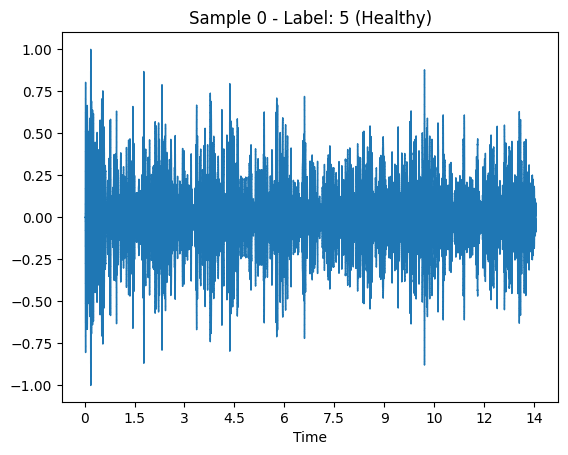

In [12]:
kauh_dataset.unit_test(idx=0)

A amostra de índice 0 corresponde ao arquivo BP100_N,N,P R M,70,F.wav, rotulada como 5 (Healthy). A taxa de amostragem é de 4000 Hz, valor bastante inferior aos 44100 Hz observados no ICBHI 2017, e a duração da gravação é de 13,55 segundos. A amplitude varia entre -0,879 e 1,000.

#### Class Distribution

A função plot_label_distribution, definida anteriormente, é chamada agora com o dataset KAUH 2021 como argumento.

Diagnosis
Healthy             105
Asthma               96
Heart Failure        54
COPD                 27
Pneumonia            15
Lung Fibrosis        12
Bronchitis            9
Pleural Effusion      6
Name: count, dtype: int64

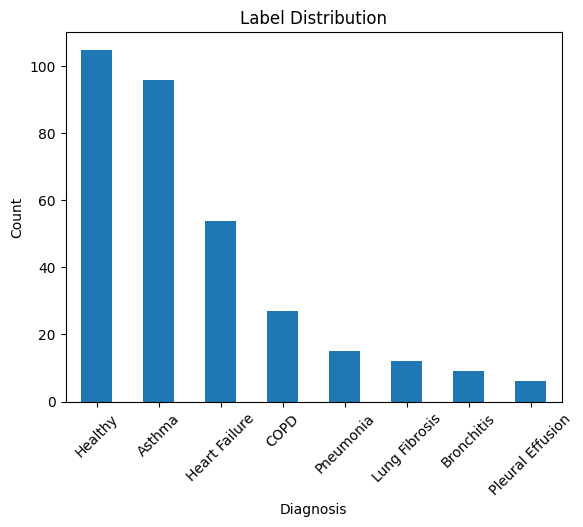

In [13]:
plot_label_distribution(kauh_dataset)

A distribuição de classes do dataset KAUH 2021 mostra-se considerablemente mais equilibrada do que a observada no ICBHI 2017, embora ainda apresente variação relevante entre classes. Healthy é a classe mais frequente, com 105 amostras, seguida por Asthma com 96, Heart Failure com 54 e COPD com 27. As classes Pneumonia, Lung Fibrosis, Bronchitis e Pleural Effusion possuem, respectivamente, 15, 12, 9 e 6 amostras.
O dataset KAUH 2021 cobre oito classes, parcialmente distintas das observadas no ICBHI 2017. Em particular, introduz três diagnósticos ausentes no dataset anterior: Heart Failure, Bronchitis e Pleural Effusion. Por outro lado, classes como URTI, LRTI e Bronchiectasis, presentes no ICBHI, não aparecem no KAUH. Essa complementaridade entre os dois datasets reforça a justificativa de combiná-los, uma vez que, isoladamente, nenhum dos dois conjuntos cobre as doze classes definidas em ALL_CLASSES. Ainda assim, mesmo após a combinação, classes como Asthma (1 amostra no ICBHI, 96 no KAUH) e LRTI (2 amostras, ausente no KAUH) permanecerão com representatividade desigual, o que deverá ser considerado nas estratégias de divisão dos dados e de treinamento do modelo.

#### Demographics

A função plot_demographic_distribution, definida anteriormente, é chamada com o dataset KAUH 2021.

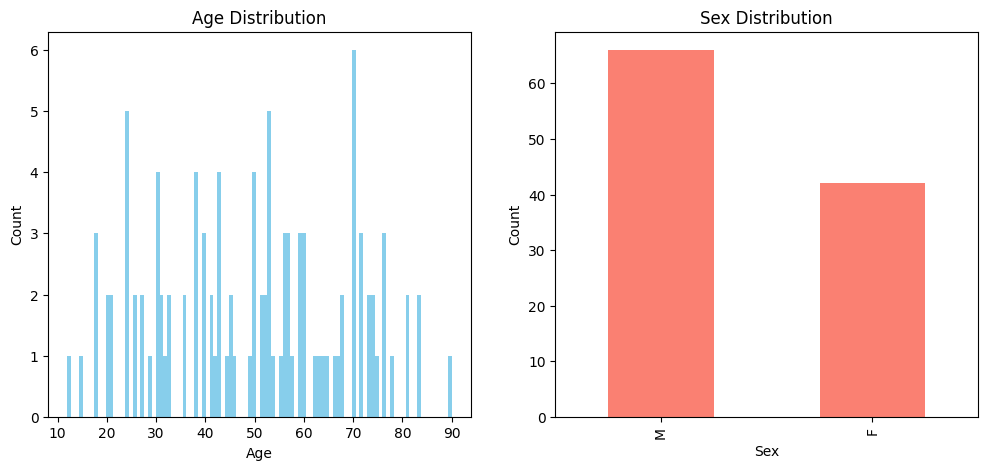

In [14]:
plot_demographic_distribution(kauh_dataset)

A distribuição de idade do dataset KAUH 2021 apresenta perfil distinto do observado no ICBHI 2017. Não há concentração de pacientes pediátricos próximos a 0 anos; em vez disso, as idades se distribuem de forma mais contínua entre aproximadamente 10 e 90 anos, com picos mais pronunciados próximos a 25, 50 e 70 anos. Diferentemente do ICBHI, não há lacuna significativa entre faixas etárias, o que sugere uma amostragem mais representativa ao longo do espectro de idade adulta.
Em relação ao sexo, observa-se desbalanceamento semelhante ao do ICBHI 2017, com aproximadamente 198 registros do sexo masculino contra cerca de 126 do sexo feminino, proporção próxima de 61% para 39%.
A combinação dos dois datasets deverá, portanto, resultar em uma distribuição de idade mais ampla e contínua, beneficiando-se da cobertura mais uniforme do KAUH 2021 nas faixas etárias intermediárias, ainda que o desbalanceamento entre sexos persista de forma semelhante em ambos os conjuntos, não devendo se anular na combinação.

#### Duration

A função plot_recording_duration_distribution, definida anteriormente, é chamada com o dataset KAUH 2021.

Shortest recording duration: 5.00 seconds
Longest recording duration: 30.00 seconds


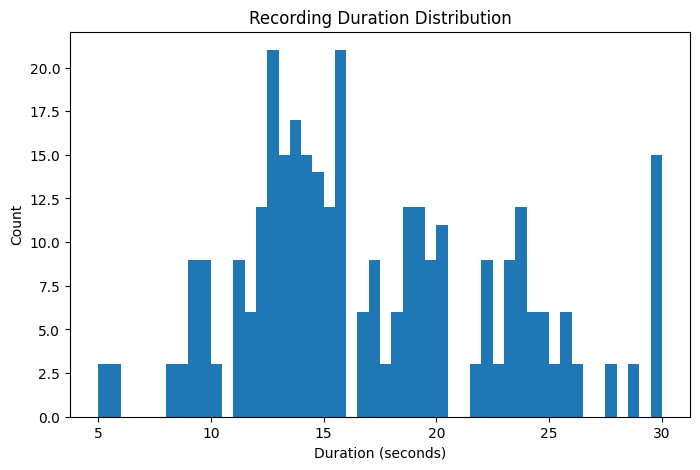

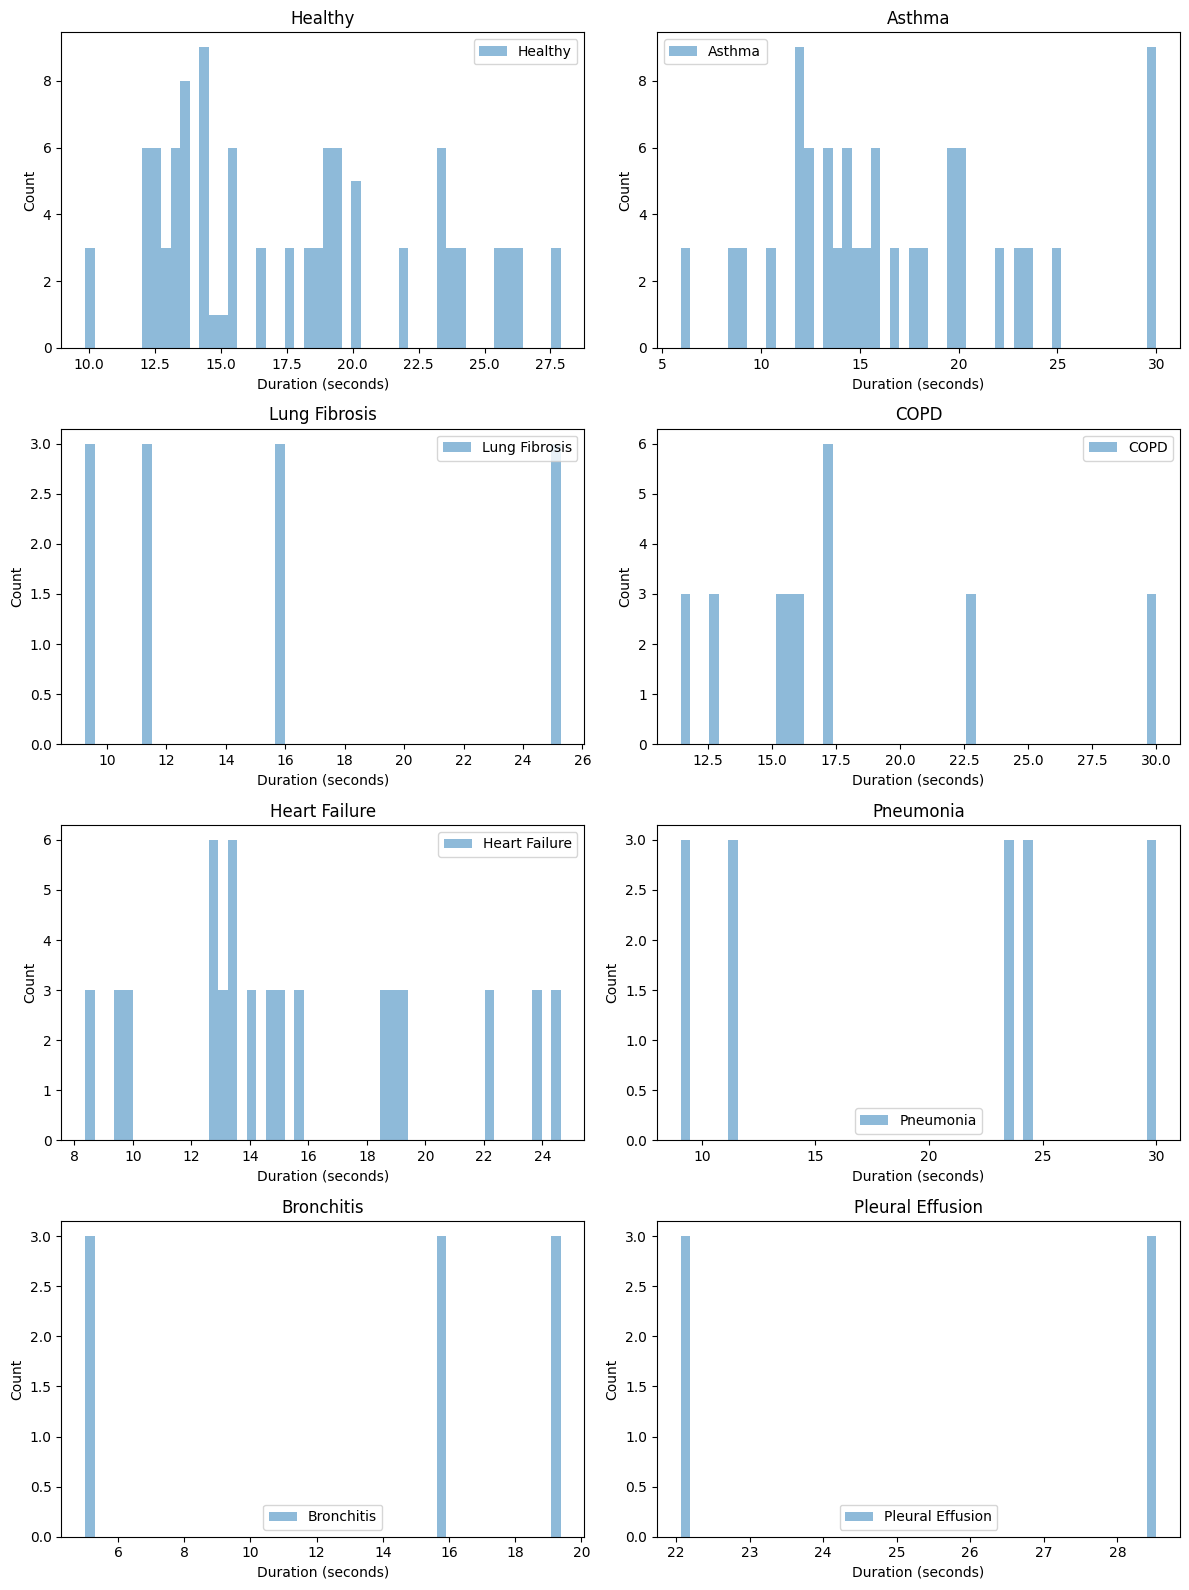

In [15]:
plot_recording_duration_distribution(kauh_dataset)

A duração mínima registrada foi de 5,00 segundos e a máxima de 30,00 segundos. Diferentemente do padrão observado no ICBHI 2017, a distribuição geral de durações no KAUH 2021 é heterogênea, sem concentração dominante em um único valor. As contagens distribuem-se de forma irregular entre 5 e 30 segundos, com picos relativos próximos a 12-16 segundos e um pico isolado em 30 segundos, este último concentrando 15 amostras.
Os histogramas por classe confirmam que essa variabilidade está presente em praticamente todos os diagnósticos. Healthy e Asthma, as classes mais numerosas, apresentam durações dispersas ao longo de praticamente toda a faixa observada, de 5 a 30 segundos. As demais classes, com menor número de amostras, também exibem durações variadas, sem padrão fixo evidente, como observado, por exemplo, em Bronchitis e Pleural Effusion, cujas poucas amostras se distribuem em pontos isolados entre 5 e 29 segundos.
Esse padrão contrasta de forma direta com o ICBHI 2017, no qual a quase totalidade das gravações possuía exatamente 20 segundos. A combinação dos dois datasets, portanto, exigirá uma etapa de padronização de duração mais robusta do que seria necessária para o ICBHI isoladamente, sendo necessário definir uma duração fixa de referência e aplicar truncamento ou padding de forma consistente a ambos os conjuntos, de modo a garantir que os espectrogramas gerados tenham dimensões compatíveis para a etapa de classificação por imagem.

### Combined Datasets

Esta seção tem como objetivo carregar o dataset combinado, unificando ICBHI 2017 e KAUH 2021 sob uma estrutura de metadados comum, etapa necessária para que o modelo de classificação seja treinado sobre o conjunto completo de classes.

É instanciada a classe CombinedAudioDataset, recebendo os mesmos parâmetros utilizados nos datasets individuais. É impresso o tamanho total do dataset combinado e exibidas as dez primeiras linhas da tabela de metadados.

In [16]:
combined_dataset = CombinedAudioDataset(DATA_FOLDER, "all", classes=ALL_CLASSES)
print(f"Dataset size: {len(combined_dataset)} samples")
combined_dataset.data.head(10)

Dataset size: 1244 samples


,Source,FilePath,Diagnosis,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment,Label,FilterCode,Sound type
0,ICBHI,ICBHI/ICBHI_final_database/101_1b1_Al_sc_Medit...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron,11,NaN,NaN
1,ICBHI,ICBHI/ICBHI_final_database/101_1b1_Pr_sc_Medit...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron,11,NaN,NaN
2,ICBHI,ICBHI/ICBHI_final_database/102_1b1_Ar_sc_Medit...,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron,5,NaN,NaN
3,ICBHI,ICBHI/ICBHI_final_database/103_2b2_Ar_mc_LittC...,Asthma,70.00,F,33.00,NaN,NaN,I103,2b2,Ar,mc,LittC2SE,0,NaN,NaN
4,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Al_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Al,sc,Litt3200,4,NaN,NaN
5,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Ar_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ar,sc,Litt3200,4,NaN,NaN
6,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Ll_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ll,sc,Litt3200,4,NaN,NaN
7,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Lr_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Lr,sc,Litt3200,4,NaN,NaN
8,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Pl_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pl,sc,Litt3200,4,NaN,NaN
9,ICBHI,ICBHI/ICBHI_final_database/104_1b1_Pr_sc_Litt3...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pr,sc,Litt3200,4,NaN,NaN


O dataset combinado possui 1244 amostras, correspondendo exatamente à soma das 920 amostras do ICBHI 2017 e das 324 amostras do KAUH 2021, o que confirma que a combinação preserva a totalidade dos registros de ambas as fontes, sem perda de dados na unificação.
A tabela de metadados resultante unifica as colunas de ambos os datasets em um único esquema. As colunas específicas do ICBHI (AdultBMI, ChildWheight, ChildHeight, RecordingIndex, AcquisitionMode, RecordingEquipment) e do KAUH (FilterCode, Sound type) coexistem na mesma tabela, sendo preenchidas com NaN nas linhas provenientes do dataset em que aquela informação não existe. Como as dez primeiras linhas exibidas pertencem ao ICBHI 2017, observa-se NaN nas colunas FilterCode e Sound type, próprias do KAUH.
Esse resultado confirma que a classe CombinedAudioDataset realiza corretamente a junção dos dois conjuntos preservando todas as colunas originais, ainda que ao custo de uma esparsidade considerável no DataFrame final, dado o baixo grau de sobreposição entre os campos de metadados das duas fontes. Esse aspecto não compromete a coluna Label, comum a ambos os datasets e essencial para a etapa de classificação, mas deve ser considerado caso os metadados demográficos ou técnicos sejam utilizados como variáveis adicionais no modelo.

#### Unit Test

É executado o método unit_test com índice 0 sobre o dataset combinado, com o objetivo de validar se o carregamento de uma amostra no conjunto unificado mantém a integridade observada anteriormente nos datasets individuais.


Sample 0:
  File name: 101_1b1_Al_sc_Meditron.wav
  Label: 11 (URTI)
  Sample rate: 44100
  Audio shape: (882000,)
  Audio dtype: float32
  Audio min value: -0.200
  Audio max value: 0.415
  Duration (s): 20.00


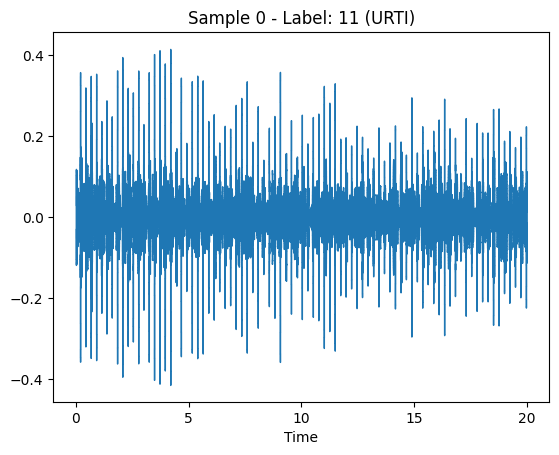

In [17]:
combined_dataset.unit_test(idx=0)

A amostra de índice 0 do dataset combinado corresponde exatamente à primeira amostra do ICBHI 2017 (101_1b1_Al_sc_Meditron.wav, rótulo 11, URTI, taxa de amostragem 44100 Hz, duração de 20 segundos, amplitude entre -0,200 e 0,415), o que é esperado dado que a ordem de concatenação preserva o ICBHI como primeiro bloco de dados. O resultado confirma que a classe CombinedAudioDataset não introduz inconsistências no carregamento individual das amostras, mantendo os valores originais de áudio e metadados inalterados após a unificação dos dois datasets.

#### Class Distribution

Análise da distribuição de classes do dataset combinado, segmentando a contagem por fonte de origem (ICBHI ou KAUH), de modo a visualizar de forma explícita a complementaridade entre os dois datasets.

A tabela de metadados combinada é agrupada por Diagnosis e Source por meio de groupby seguido de size() e unstack, resultando em um DataFrame com uma coluna de contagem para cada fonte. A soma das colunas fornece o total geral por diagnóstico, ordenado de forma decrescente e exibido com display. Em seguida, é gerado um gráfico de barras agrupadas, com uma cor para cada fonte, e os valores numéricos são exibidos sobre cada barra por meio de bar_label.

Diagnosis
COPD                820
Healthy             140
Asthma               97
Heart Failure        54
Pneumonia            52
URTI                 23
Bronchiectasis       16
Bronchiolitis        13
Lung Fibrosis        12
Bronchitis            9
Pleural Effusion      6
LRTI                  2
dtype: int64

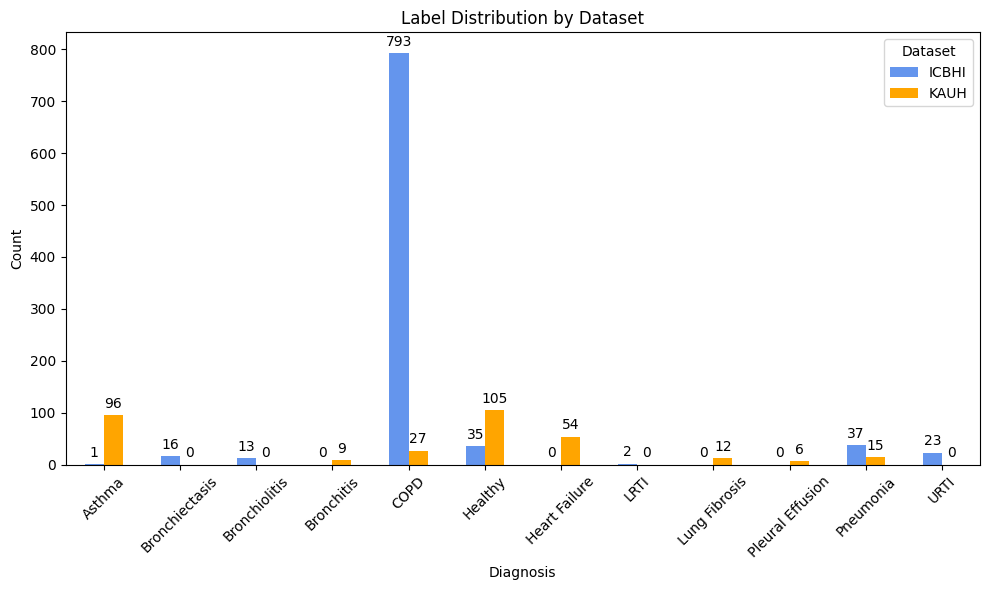

In [18]:
counts_df = (
    combined_dataset.data
    .groupby(["Diagnosis", "Source"])
    .size()
    .unstack(fill_value=0)
)
label_counts = counts_df.sum(axis=1).sort_values(ascending=False)
display(label_counts)

colors = ["cornflowerblue", "orange"]
ax = counts_df.plot(kind="bar", figsize=(10, 6), color=colors)
ax.set_title("Label Distribution by Dataset")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Dataset")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

O gráfico evidencia de forma clara a complementaridade entre os dois datasets discutida anteriormente. Asthma, virtualmente ausente no ICBHI (1 amostra), é a segunda classe mais numerosa no KAUH (96 amostras), totalizando 97 no conjunto combinado. De forma inversa, COPD é amplamente dominada pelo ICBHI (793 amostras) frente a uma contribuição menor do KAUH (27 amostras), totalizando 820. Healthy é a classe mais equilibrada entre as duas fontes, com 35 do ICBHI e 105 do KAUH, totalizando 140.
Quatro classes permanecem exclusivas de uma única fonte mesmo após a combinação: Bronchiectasis, Bronchiolitis, LRTI e URTI aparecem apenas no ICBHI, enquanto Bronchitis, Heart Failure, Lung Fibrosis e Pleural Effusion aparecem apenas no KAUH. Esse padrão indica que, para essas oito classes, o modelo será treinado com exemplos provenientes de uma única fonte de gravação, o que pode introduzir viés relacionado a características técnicas específicas do dataset de origem, como equipamento de gravação ou taxa de amostragem, e não exclusivamente ao padrão acústico da patologia em si.
Apesar da combinação ampliar a cobertura para dez das doze classes definidas em ALL_CLASSES, o desbalanceamento geral persiste de forma acentuada, com COPD ainda concentrando a maior parte das amostras totais, e classes como LRTI e Pleural Effusion permanecendo com representatividade mínima.